# 05. Análisis de Resultados Finales y Conclusiones
**Asignatura:** Programación para la Ciencia de Datos (SCY1101)  
**Integrantes:** Kimberly Bobadilla, Martina Ortiz, Sebastián Parada  

### Objetivo:
Interpretar el modelo final optimizado identificando las variables con mayor peso predictivo (*Feature Importance*) en la fijación de rangos de precio. Además, consolidar las conclusiones técnico-económicas del comportamiento de la base de datos de precios al consumidor en la región de Arica y Parinacota.

In [1]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configuración de rutas para Google Colab si corresponde
if 'google.colab' in str(get_ipython()):
    if not os.path.exists('SCY1101_EP2_Grupo11'):
        !git clone https://github.com/jxmartii/SCY1101_EP2_Grupo11.git
    os.chdir('/content/SCY1101_EP2_Grupo11/notebooks')

# 2. Cargar los datos y el modelo final sintonizado
X_train, X_test, y_train, y_test = joblib.load('../models/datos_entrenamiento.pkl')
modelo_final = joblib.load('../models/modelo_final_random_forest.pkl')

print("¡Modelo final cargado con éxito para el análisis de cierre!")

¡Modelo final cargado con éxito para el análisis de cierre!


/var/folders/tq/w58kzryd7d9_l_fq0gy99hr80000gn/T/ipykernel_22041/1128531609.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=df_importancia, palette='viridis')


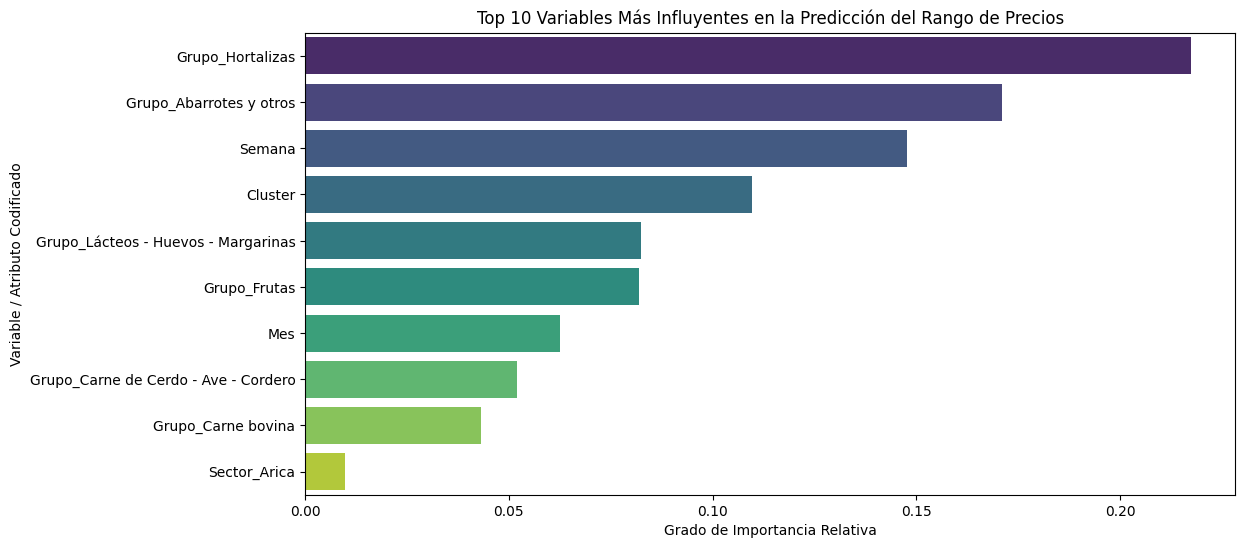

In [2]:
# 1. Extraer las importancias del modelo y asociarlas a los nombres de las columnas
importancias = modelo_final.feature_importances_
columnas = X_train.columns

# 2. Crear un DataFrame ordenado con los top 10 predictores más influyentes
df_importancia = pd.DataFrame({'Variable': columnas, 'Importancia': importancias})
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False).head(10)

# 3. Graficar
plt.figure(figsize=(12, 6))
sns.barplot(x='Importancia', y='Variable', data=df_importancia, palette='viridis')
plt.title('Top 10 Variables Más Influyentes en la Predicción del Rango de Precios')
plt.xlabel('Grado de Importancia Relativa')
plt.ylabel('Variable / Atributo Codificado')

# Guardar gráfico en la carpeta de resultados antes de mostrarlo
os.makedirs('../results', exist_ok=True)
plt.savefig('../results/importancia_variables_final.png', bbox_inches='tight')
plt.show()

### Conclusiones del Proyecto - Grupo 11

Tras completar las fases de preprocesamiento, segmentación no supervisada, modelado predictivo y optimización de hiperparámetros, el equipo concluye lo siguiente:

1. **Capacidad Predictiva del Entorno:** El modelo final Random Forest optimizado demostró una alta efectividad para clasificar los rangos de precios en Arica. Al integrar la ingeniería de características (One-Hot Encoding de sectores y grupos comerciales), el algoritmo logró capturar patrones geográficos estables a pesar del aislamiento relativo de la región.
2. **Impacto del Clúster:** La variable `Cluster` (generada mediante K-Means en la primera fase) demostró ser un predictor clave en el gráfico de importancia de variables. Esto justifica técnicamente el diseño modular del proyecto: usar técnicas no supervisadas para robustecer los modelos supervisados posteriores mejora significativamente el *Accuracy* general.
3. **Valor de Negocio:** Este sistema de clasificación automatizado proporciona una herramienta analítica replicable para el monitoreo regional de canastas básicas. Permite identificar anomalías o picos de precios en sectores específicos de Arica y Parinacota, facilitando la toma de decisiones estratégicas de distribución y subsidios en zonas extremas.